In [11]:
import pandas as pd

df_train_from_scratch_fix = pd.read_csv("results/train_loss-from_scratch-fix_LR.csv")
df_train_from_scratch_exp = pd.read_csv("results/train_loss-from_scratch-exp_LR.csv")
df_train_from_scratch_tpt = pd.read_csv("results/train_loss-from_scratch-exp_LR_trumpet.csv")
df_train_finetuned_exp = pd.read_csv("results/train_loss-finetuned-exp_LR.csv")

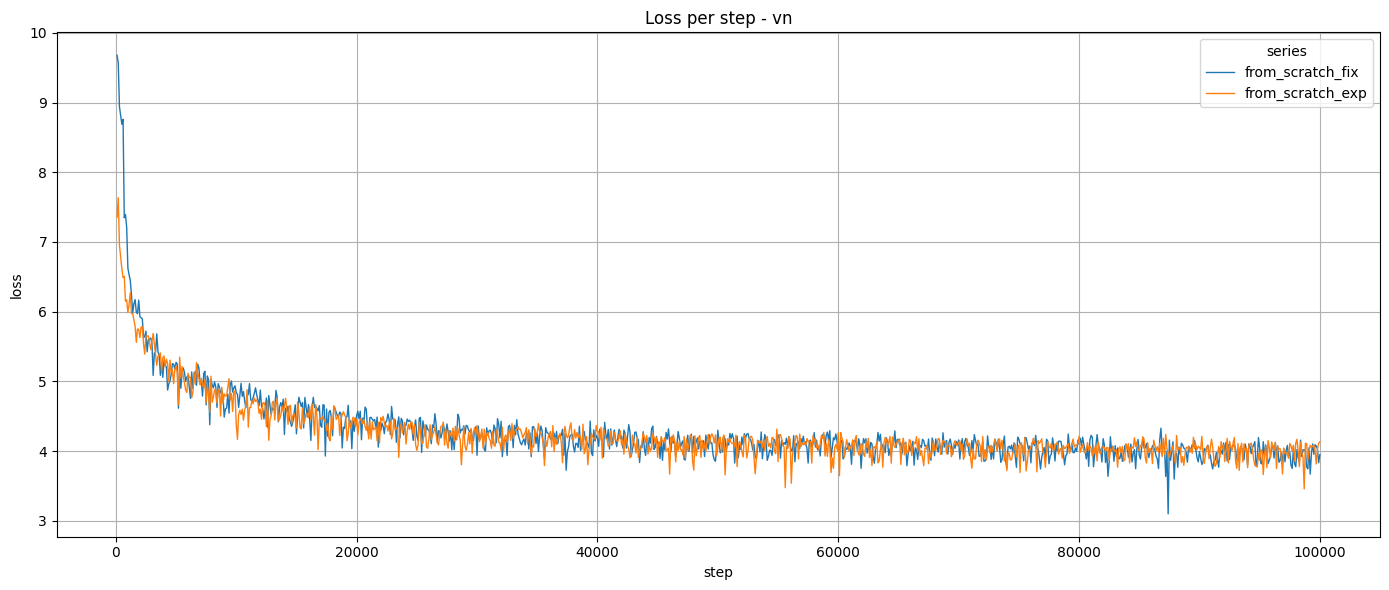

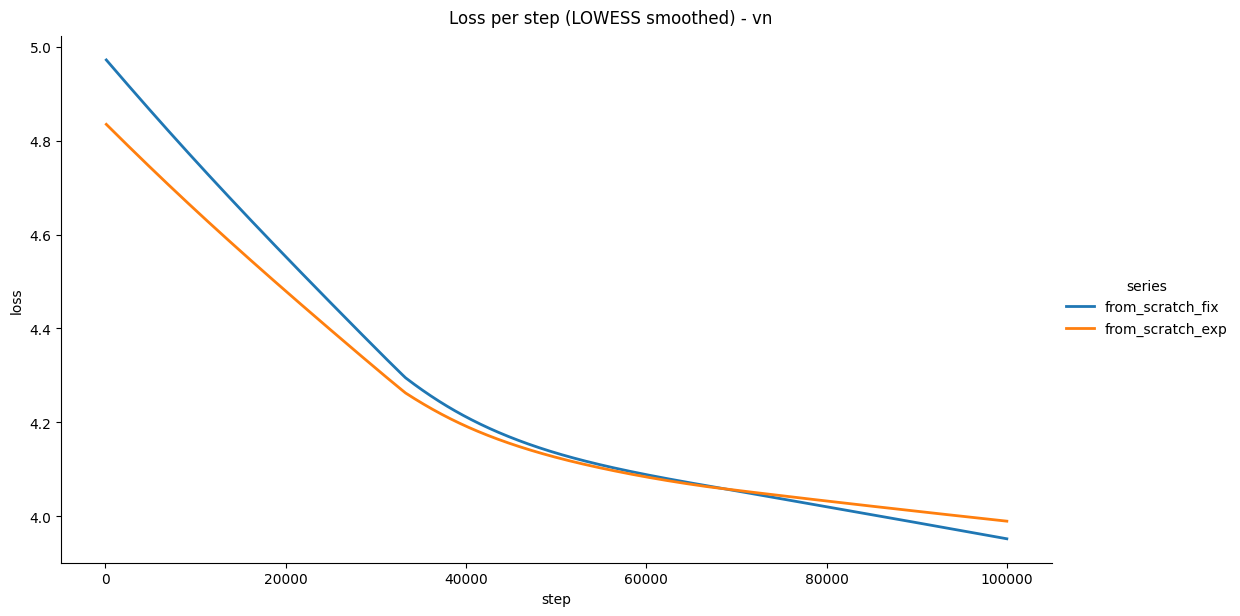

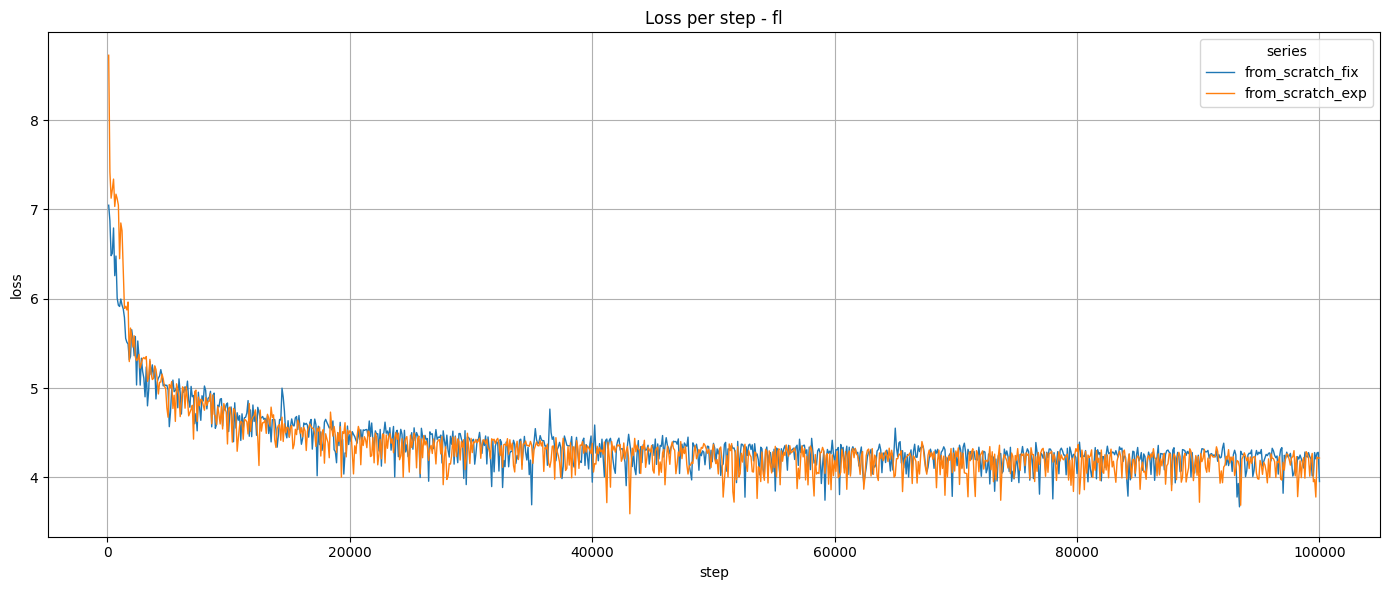

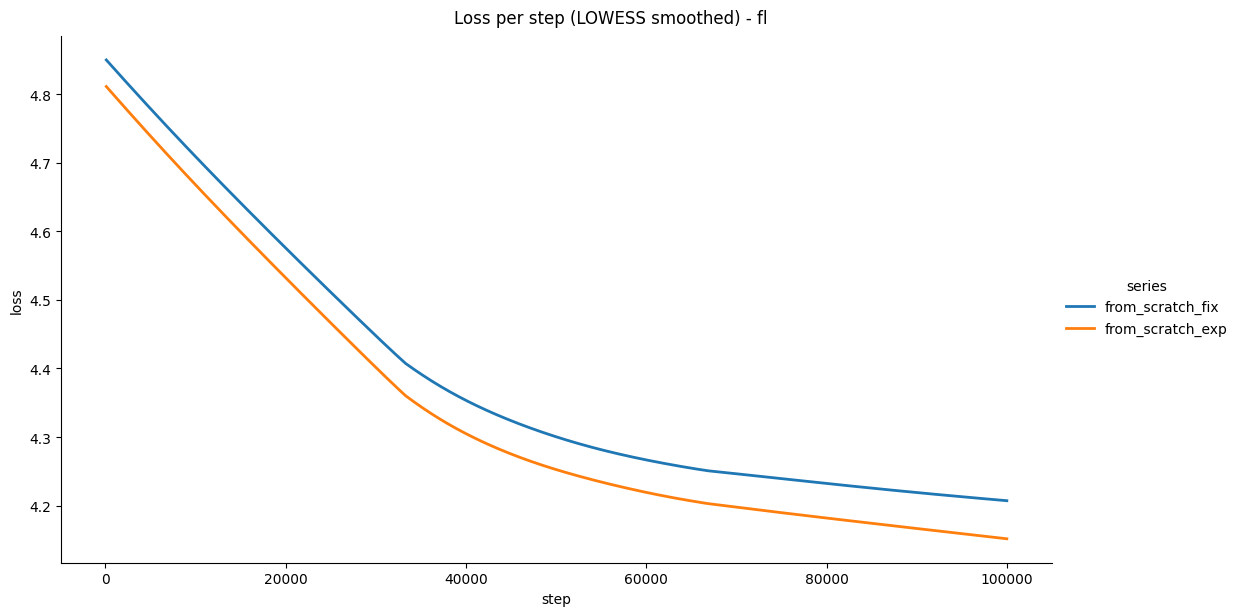

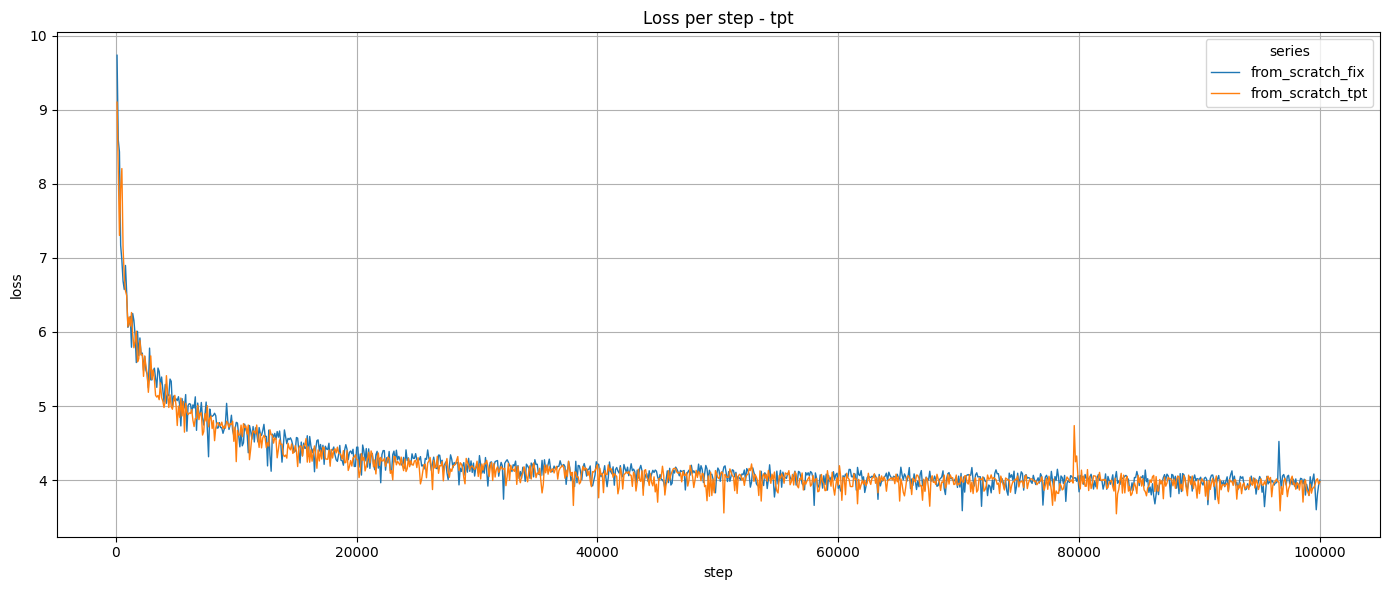

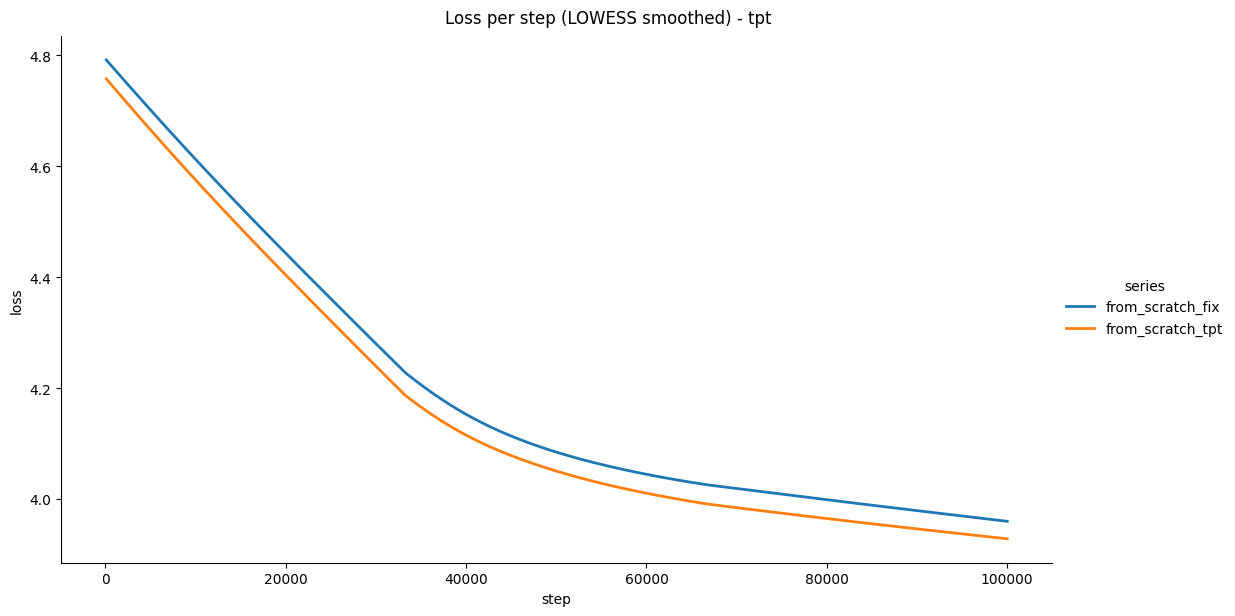

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# optional: clean whitespace in headers
for d in [df_train_from_scratch_fix, df_train_from_scratch_exp, df_train_from_scratch_tpt, df_train_finetuned_exp]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_train_from_scratch_fix),
    ("from_scratch_exp", df_train_from_scratch_exp),
    ("from_scratch_tpt", df_train_from_scratch_tpt),
    # ("finetuned_exp", df_train_finetuned_exp),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "run": run_name,
                "series": run_name,
            }))

    if not rows:
        print(f"No valid loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    # Normal plot
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=plot_df,
        x="Step",
        y="loss",
        hue="series",
        linewidth=1
    )
    plt.title(f"Loss per step - {instrument}")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LOWESS-smoothed trend lines
    g = sns.lmplot(
        data=plot_df,
        x="Step",
        y="loss",
        hue="series",
        lowess=True,
        scatter=False,
        height=6,
        aspect=1.8,
        line_kws={"lw": 2}
    )

    g.set_axis_labels("step", "loss")
    g.fig.suptitle(f"Loss per step (LOWESS smoothed) - {instrument}", y=1.02)
    plt.show()

In [13]:
df_val_from_scratch_fix = pd.read_csv("results/val_loss-from_scratch-fix_LR.csv")
df_val_from_scratch_exp = pd.read_csv("results/val_loss-from_scratch-exp_LR.csv")
df_val_from_scratch_tpt = pd.read_csv("results/val_loss-from_scratch-exp_LR_trumpet.csv")

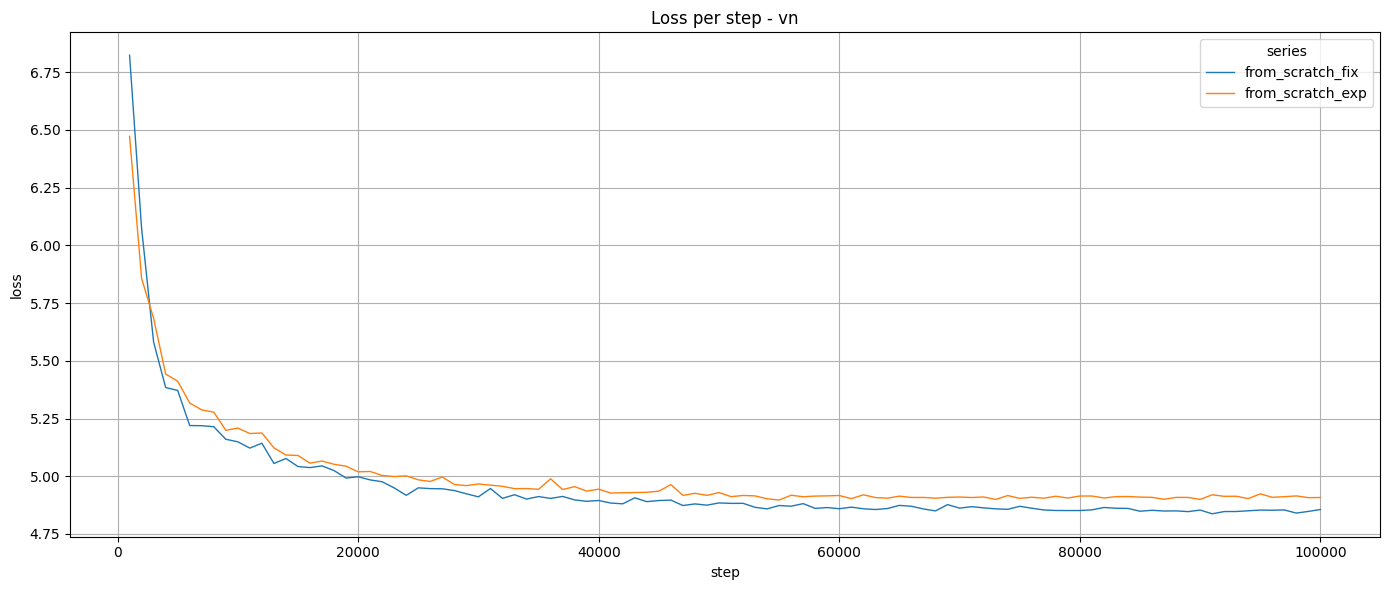

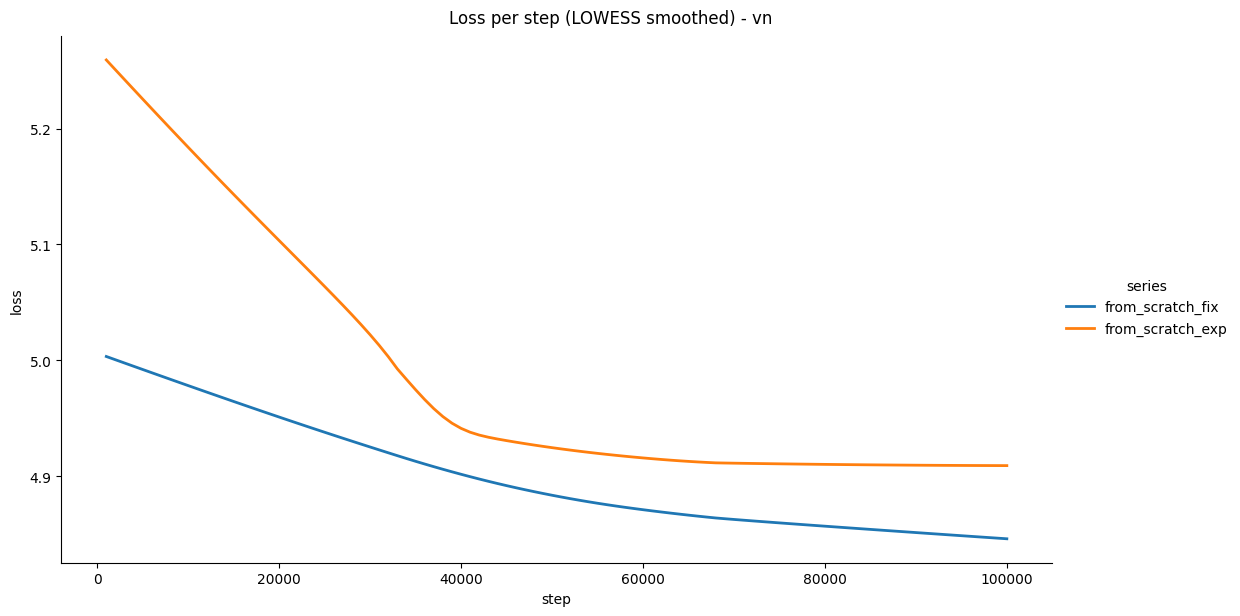

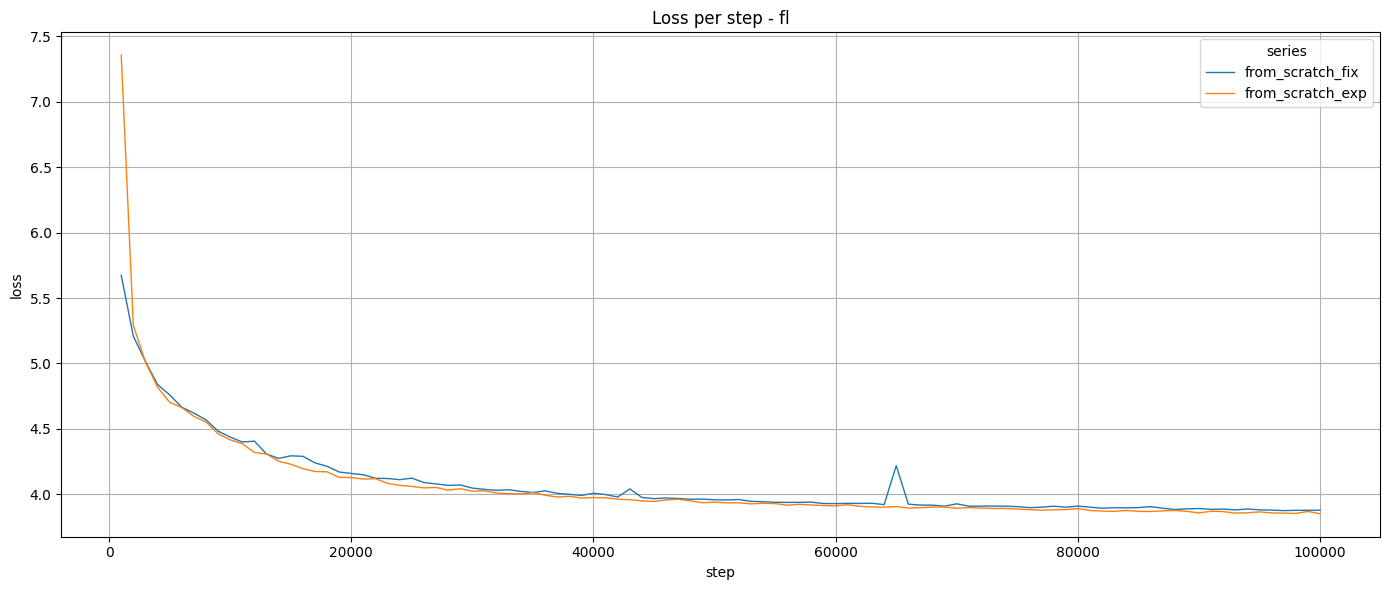

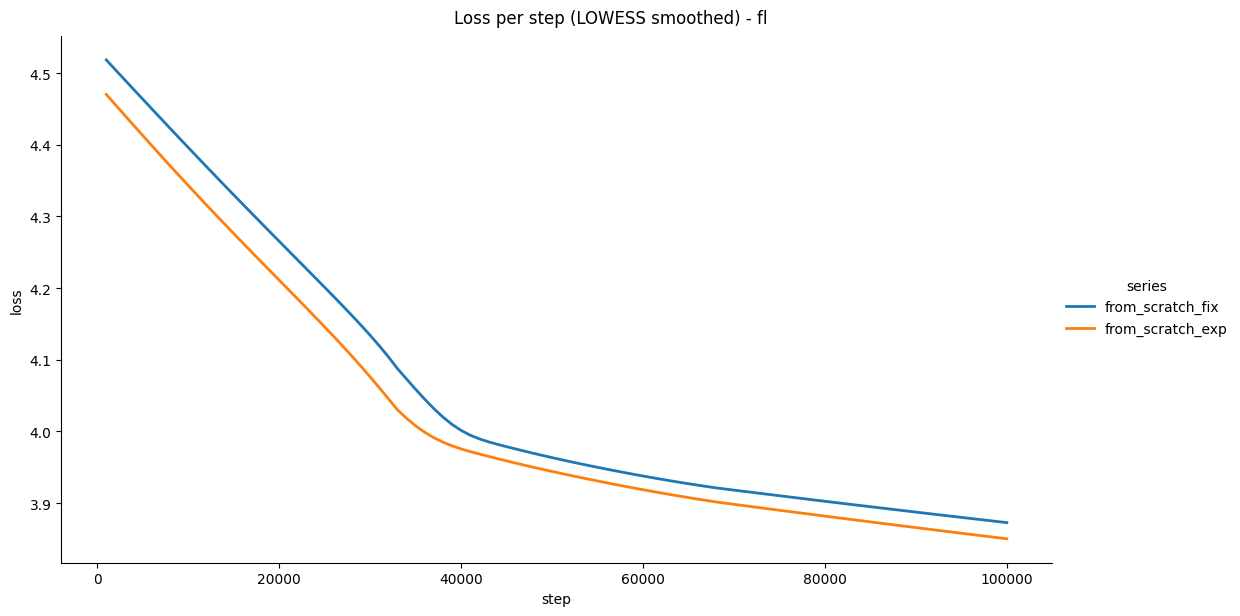

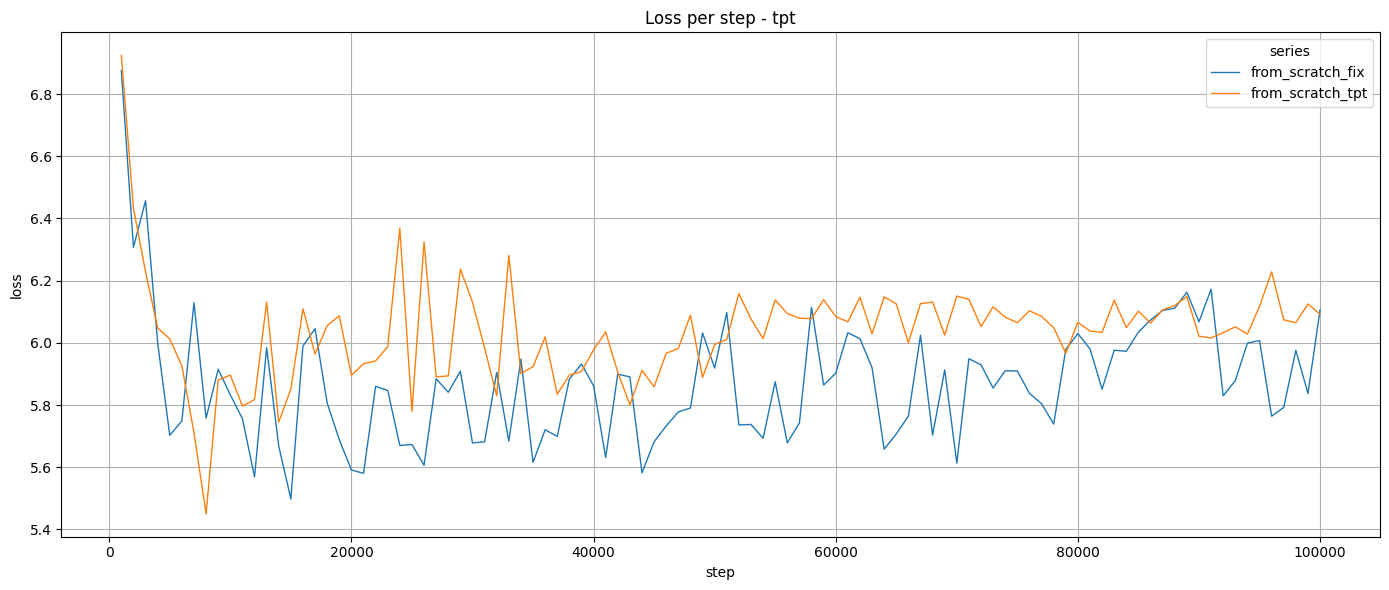

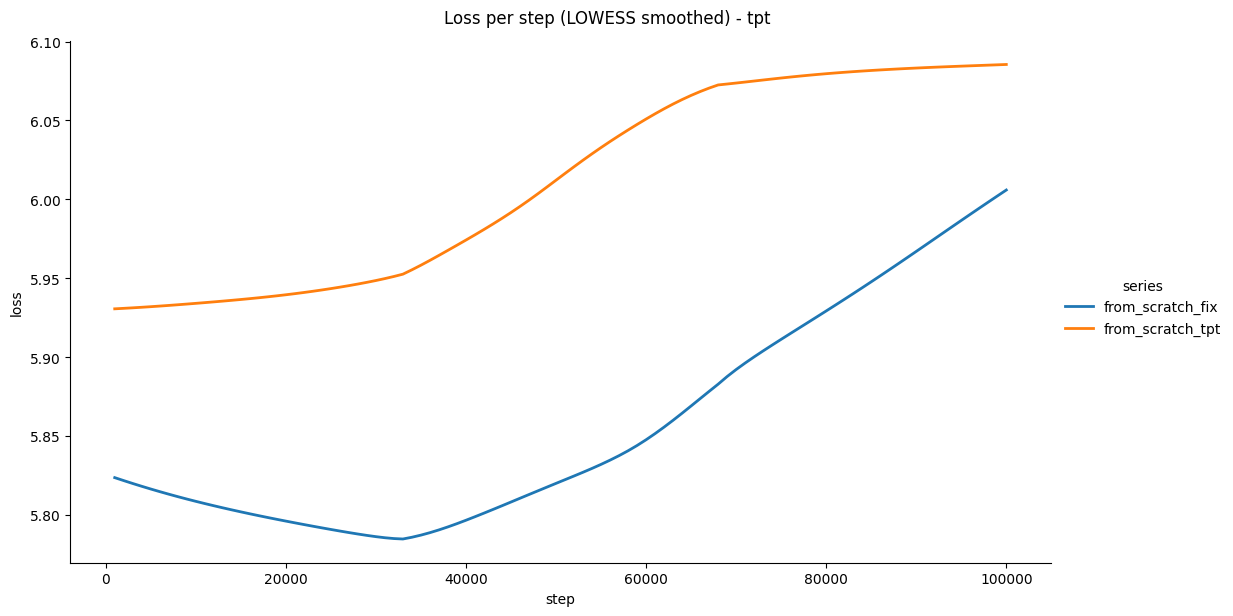

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# optional: clean whitespace in headers
for d in [df_val_from_scratch_fix, df_val_from_scratch_exp, df_val_from_scratch_tpt]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_val_from_scratch_fix),
    ("from_scratch_exp", df_val_from_scratch_exp),
    ("from_scratch_tpt", df_val_from_scratch_tpt),
    # ("finetuned_exp", df_val_finetuned_exp),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - val_loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "run": run_name,
                "series": run_name,
            }))

    if not rows:
        print(f"No valid loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    # Normal plot
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=plot_df,
        x="Step",
        y="loss",
        hue="series",
        linewidth=1
    )
    plt.title(f"Loss per step - {instrument}")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LOWESS-smoothed trend lines
    g = sns.lmplot(
        data=plot_df,
        x="Step",
        y="loss",
        hue="series",
        lowess=True,
        scatter=False,
        height=6,
        aspect=1.8,
        line_kws={"lw": 2}
    )

    g.set_axis_labels("step", "loss")
    g.fig.suptitle(f"Loss per step (LOWESS smoothed) - {instrument}", y=1.02)
    plt.show()

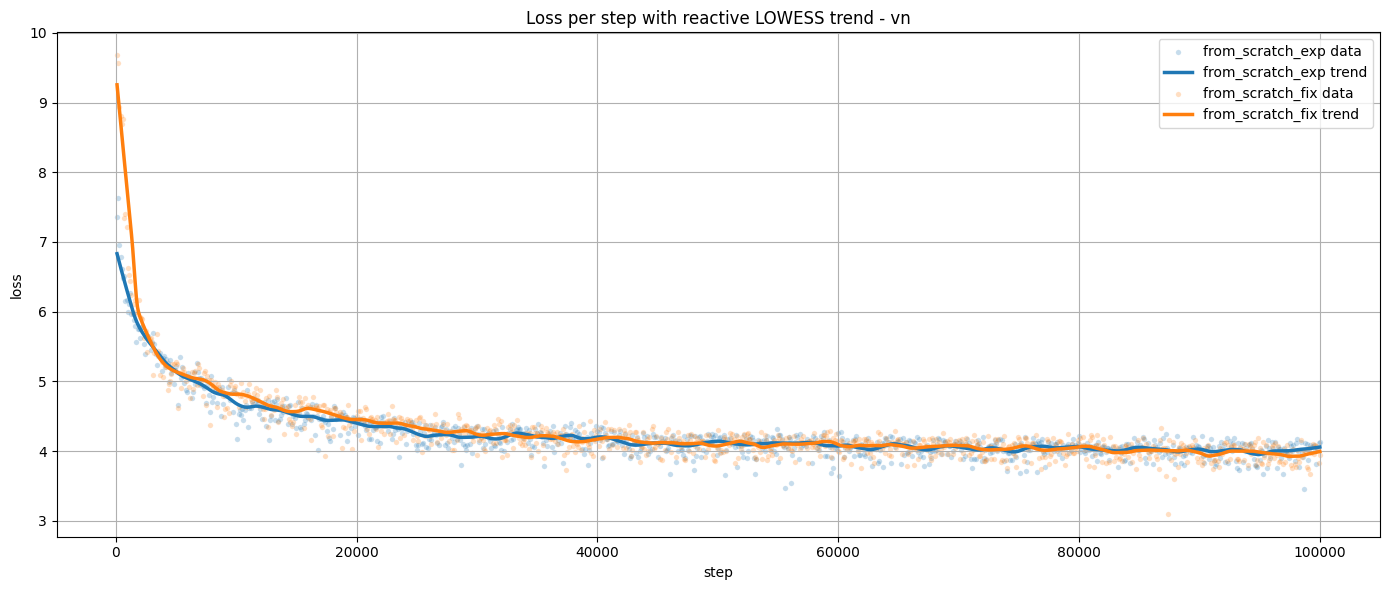

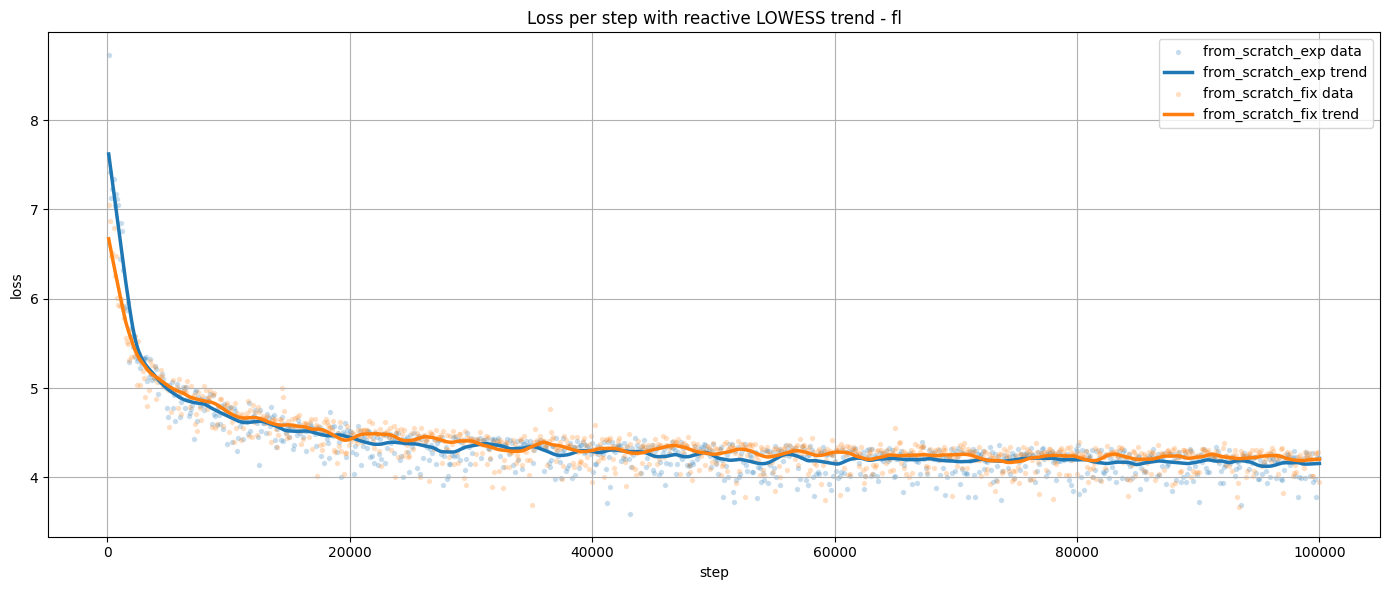

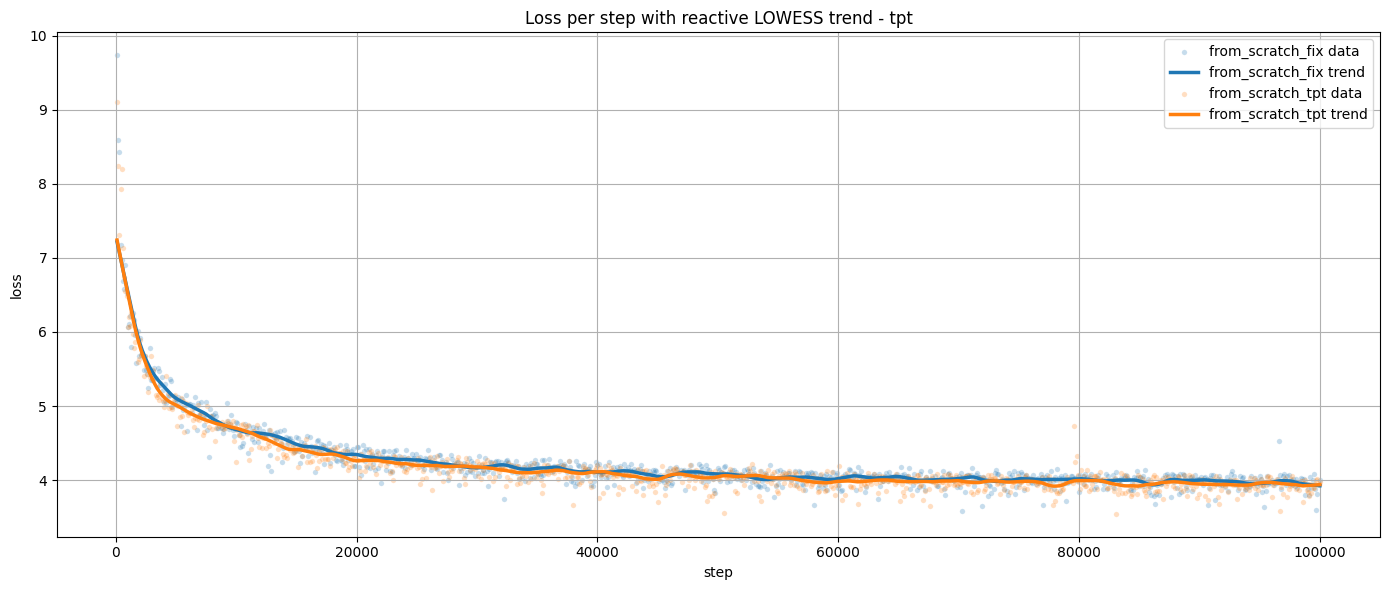

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_train_from_scratch_fix, df_train_from_scratch_exp, df_train_from_scratch_tpt, df_train_finetuned_exp]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_train_from_scratch_fix),
    ("from_scratch_exp", df_train_from_scratch_exp),
    ("from_scratch_tpt", df_train_from_scratch_tpt),
    # ("finetuned_exp", df_train_finetuned_exp),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "series": run_name,
            }))

    if not rows:
        print(f"No valid loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    palette = sns.color_palette("tab10", n_colors=plot_df["series"].nunique())

    for color, (series_name, group) in zip(palette, plot_df.groupby("series")):
        group = group.sort_values("Step")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.25,
            s=15,
            label=f"{series_name} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.03,   # smaller = more reactive
            return_sorted=True
        )
        ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, lw=2.5, label=f"{series_name} trend")

    ax.set_title(f"Loss per step with reactive LOWESS trend - {instrument}")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

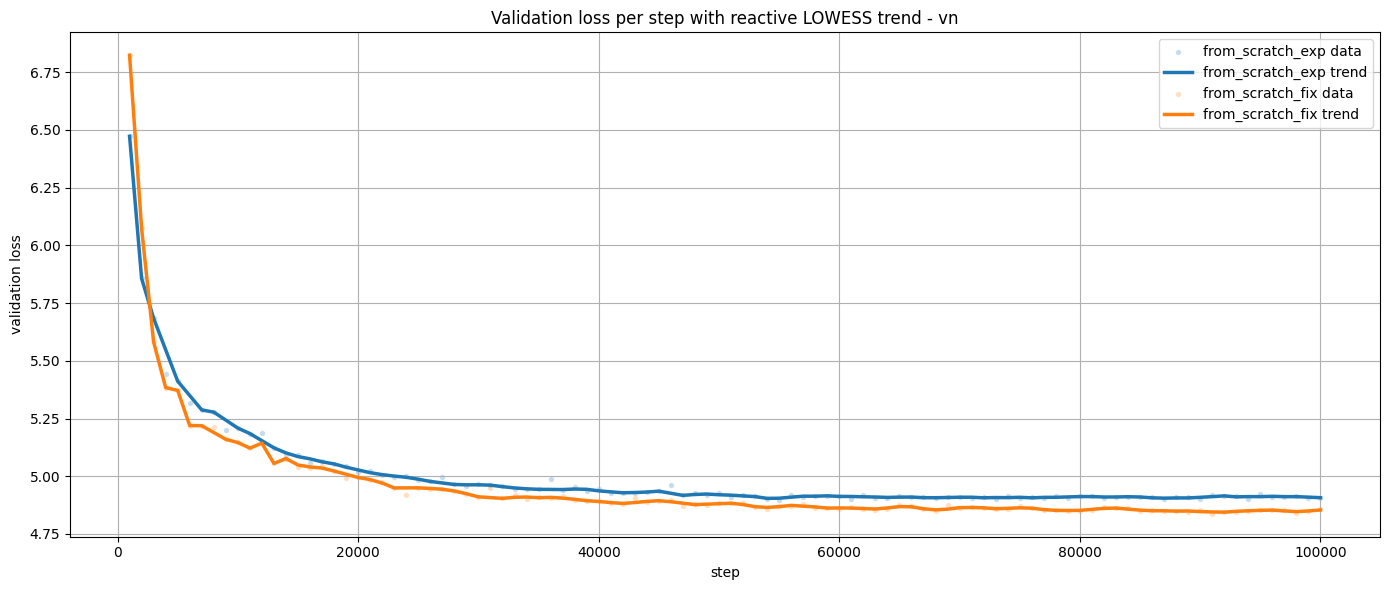

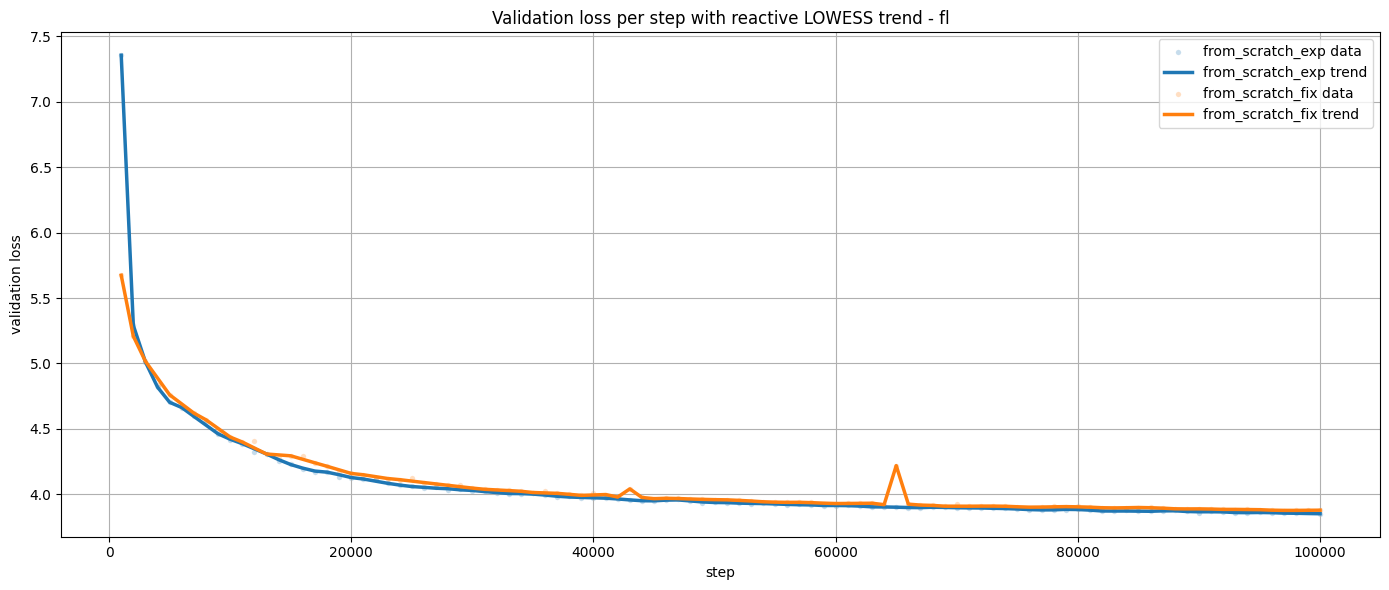

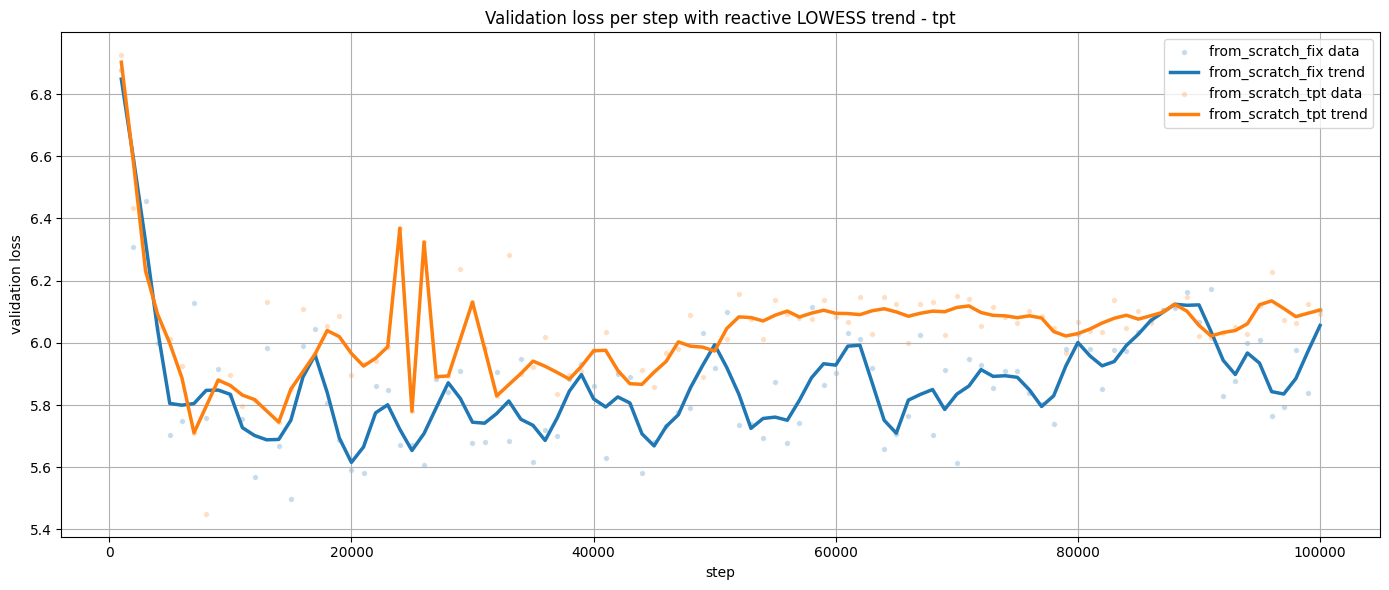

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_val_from_scratch_fix, df_val_from_scratch_exp, df_val_from_scratch_tpt]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_val_from_scratch_fix),
    ("from_scratch_exp", df_val_from_scratch_exp),
    ("from_scratch_tpt", df_val_from_scratch_tpt),
    # ("finetuned_exp", df_val_finetuned_exp),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - val_loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "series": run_name,
            }))

    if not rows:
        print(f"No valid validation loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    palette = sns.color_palette("tab10", n_colors=plot_df["series"].nunique())

    for color, (series_name, group) in zip(palette, plot_df.groupby("series")):
        group = group.sort_values("Step")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.25,
            s=15,
            label=f"{series_name} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.05,
            return_sorted=True
        )
        ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, lw=2.5, label=f"{series_name} trend")

    ax.set_title(f"Validation loss per step with reactive LOWESS trend - {instrument}")
    ax.set_xlabel("step")
    ax.set_ylabel("validation loss")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

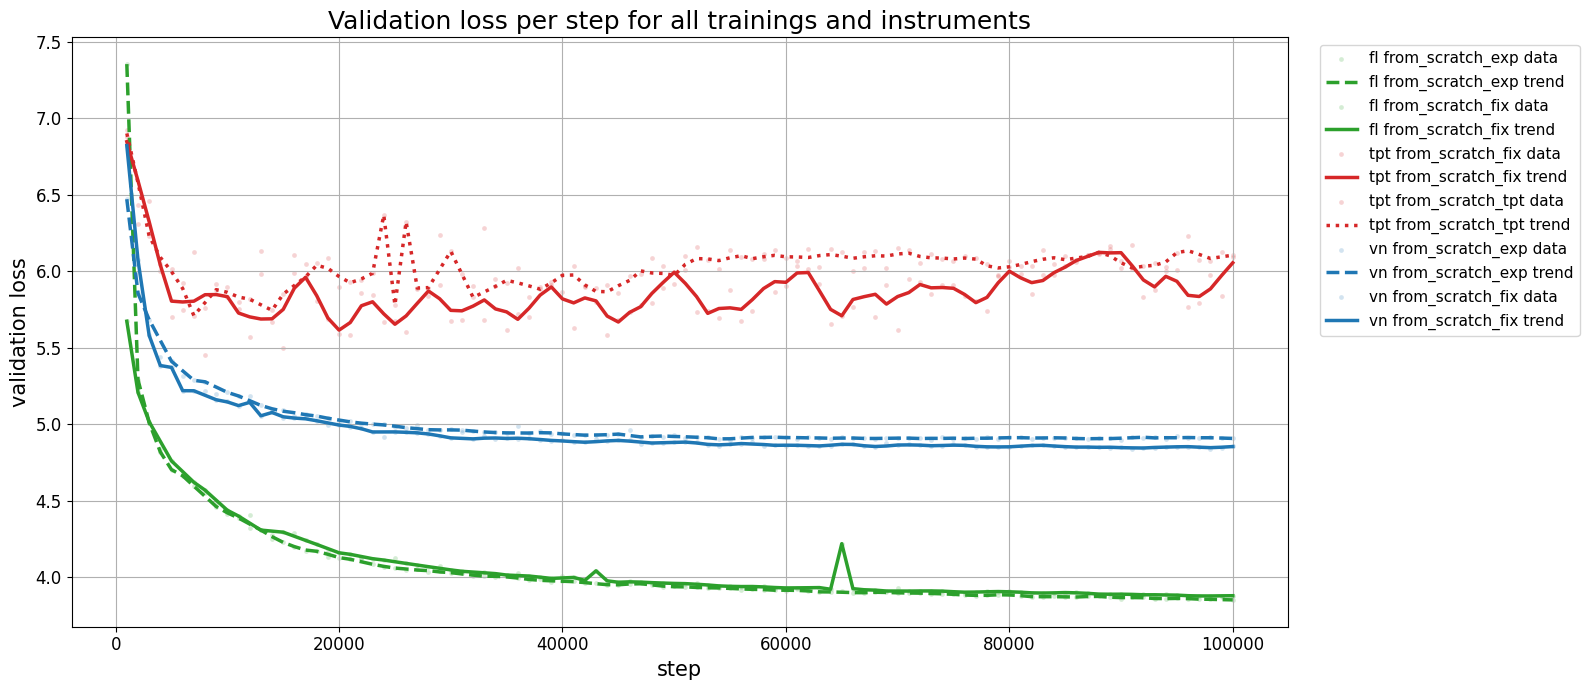

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_val_from_scratch_fix, df_val_from_scratch_exp, df_val_from_scratch_tpt]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_val_from_scratch_fix),
    ("from_scratch_exp", df_val_from_scratch_exp),
    ("from_scratch_tpt", df_val_from_scratch_tpt),
    # ("finetuned_exp", df_val_finetuned_exp),
]

instrument_colors = {
    "vn": "#1f77b4",   # blue
    "fl": "#2ca02c",   # green
    "tpt": "#d62728",  # red
}

run_styles = {
    "from_scratch_fix": "-",
    "from_scratch_exp": "--",
    "from_scratch_tpt": ":",
    # "finetuned_exp": "-.",
}

rows = []
for run_name, d in runs:
    if "Step" not in d.columns:
        continue

    for instrument in instruments:
        col = f"{instrument} - val_loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "instrument": instrument,
                "run": run_name,
                "series": f"{instrument} {run_name}",
            }))

if not rows:
    print("No valid validation loss columns found.")
else:
    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(16, 7))
    ax = plt.gca()

    for (instrument, run_name), group in plot_df.groupby(["instrument", "run"]):
        group = group.sort_values("Step")
        color = instrument_colors.get(instrument, "gray")
        linestyle = run_styles.get(run_name, "-")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.20,
            s=12,
            label=f"{instrument} {run_name} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.05,
            return_sorted=True
        )
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            color=color,
            linestyle=linestyle,
            lw=2.5,
            label=f"{instrument} {run_name} trend"
        )

    ax.set_title("Validation loss per step for all trainings and instruments", fontsize=18)
    ax.set_xlabel("step", fontsize=15)
    ax.set_ylabel("validation loss", fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()

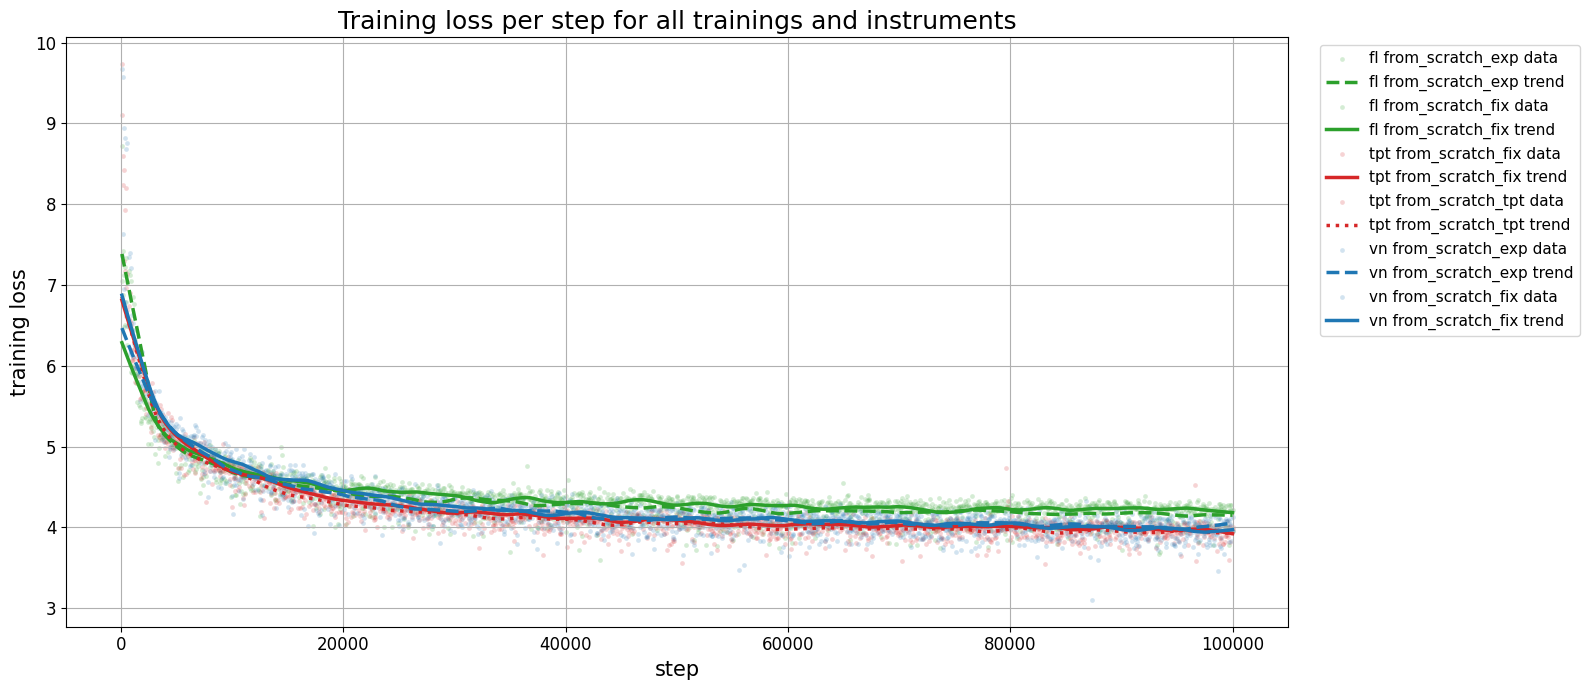

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_train_from_scratch_fix, df_train_from_scratch_exp, df_train_from_scratch_tpt]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch_fix", df_train_from_scratch_fix),
    ("from_scratch_exp", df_train_from_scratch_exp),
    ("from_scratch_tpt", df_train_from_scratch_tpt),
    # ("finetuned_exp", df_train_finetuned_exp),
]

instrument_colors = {
    "vn": "#1f77b4",   # blue
    "fl": "#2ca02c",   # green
    "tpt": "#d62728",  # red
}

run_styles = {
    "from_scratch_fix": "-",
    "from_scratch_exp": "--",
    "from_scratch_tpt": ":",
    # "finetuned_exp": "-.",
}

rows = []
for run_name, d in runs:
    if "Step" not in d.columns:
        continue

    for instrument in instruments:
        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "instrument": instrument,
                "run": run_name,
                "series": f"{instrument} {run_name}",
            }))

if not rows:
    print("No valid training loss columns found.")
else:
    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(16, 7))
    ax = plt.gca()

    for (instrument, run_name), group in plot_df.groupby(["instrument", "run"]):
        group = group.sort_values("Step")
        color = instrument_colors.get(instrument, "gray")
        linestyle = run_styles.get(run_name, "-")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.20,
            s=12,
            label=f"{instrument} {run_name} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.05,
            return_sorted=True
        )
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            color=color,
            linestyle=linestyle,
            lw=2.5,
            label=f"{instrument} {run_name} trend"
        )

    ax.set_title("Training loss per step for all trainings and instruments", fontsize=18)
    ax.set_xlabel("step", fontsize=15)
    ax.set_ylabel("training loss", fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()

In [27]:
df_val_base_model_exp = pd.read_csv("results/val_loss-base_model-exp_LR.csv")
df_train_base_model_exp = pd.read_csv("results/train_loss-base_model-exp_LR.csv")

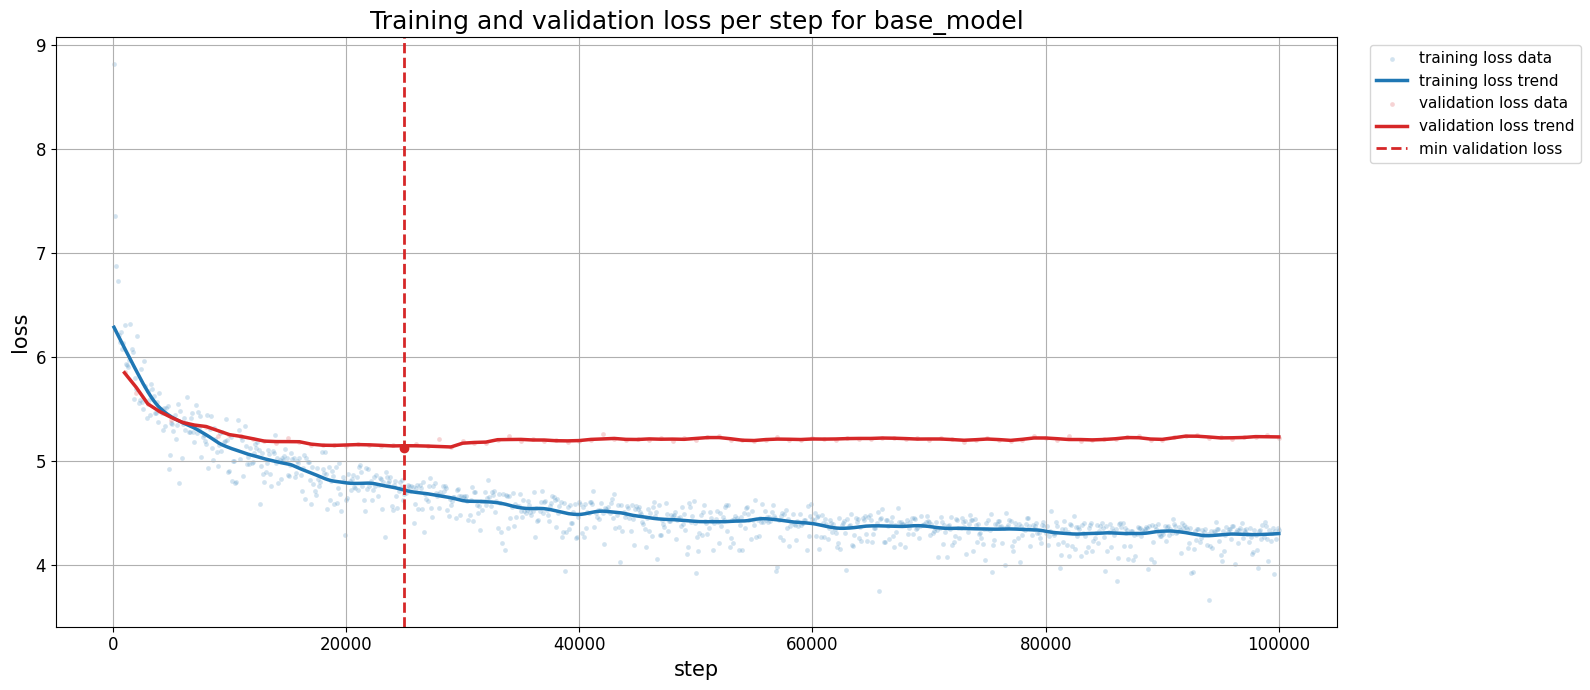

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

df_val_base_model_exp = pd.read_csv("results/val_loss-base_model-exp_LR.csv")
df_train_base_model_exp = pd.read_csv("results/train_loss-base_model-exp_LR.csv")

df_val_base_model_exp.columns = df_val_base_model_exp.columns.str.strip()
df_train_base_model_exp.columns = df_train_base_model_exp.columns.str.strip()

if "Step" not in df_train_base_model_exp.columns or "Step" not in df_val_base_model_exp.columns:
    print("Missing Step column.")
else:
    train_df = pd.DataFrame({
        "Step": df_train_base_model_exp["Step"],
        "loss": df_train_base_model_exp["base_model - loss"],
        "metric": "training loss",
    })

    val_df = pd.DataFrame({
        "Step": df_val_base_model_exp["Step"],
        "loss": df_val_base_model_exp["base_model - val_loss"],
        "metric": "validation loss",
    })

    plot_df = pd.concat([train_df, val_df], ignore_index=True).dropna()

    metric_colors = {
        "training loss": "#1f77b4",
        "validation loss": "#d62728",
    }

    min_val_row = val_df.loc[val_df["loss"].idxmin()]
    min_val_step = min_val_row["Step"]
    min_val_loss = min_val_row["loss"]

    plt.figure(figsize=(16, 7))
    ax = plt.gca()

    for metric, group in plot_df.groupby("metric"):
        group = group.sort_values("Step")
        color = metric_colors.get(metric, "gray")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.20,
            s=12,
            label=f"{metric} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.05,
            return_sorted=True
        )
        ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, lw=2.5, label=f"{metric} trend")

    ax.axvline(min_val_step, color="#d62728", linestyle="--", linewidth=2, label="min validation loss")
    ax.scatter([min_val_step], [min_val_loss], color="#d62728", zorder=5)

    ax.set_title("Training and validation loss per step for base_model", fontsize=18)
    ax.set_xlabel("step", fontsize=15)
    ax.set_ylabel("loss", fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()